In [ ]:
# !pip install fredapi

  Using cached fredapi-0.5.2-py3-none-any.whl.metadata (5.0 kB)
Using cached fredapi-0.5.2-py3-none-any.whl (11 kB)


In [3]:
import os
from dotenv import load_dotenv
from fredapi import Fred

In [ ]:
# Importing libraries
import os 
from dotenv import load_dotenv
from fredapi import Fred # Fred API
import numpy as np # linear algebra
import pandas as pd # data processin

pd.set_option('display.max_columns',500)
pd.set_option('display.max_rows',500)

# Visual 
import matplotlib.pyplot as plt # Visual tool
import seaborn as sns # style tool
import plotly.express as px
sns.set_theme()

In [ ]:
# Upload all the variables from the file .env
load_dotenv()

# Read the Fred API key 
fred_key = os.getenv('FRED_API_KEY')

# Starting Fred
fred = Fred(api_key=fred_key)

In [ ]:
# We can get the result for an argment of many indicators: unemployment, m2, S&P, Dow Jones, etc.

# Parameters: limit=1000, order_by=None, sort_order=None, filter=None)
sp_search = fred.search('S&P', order_by = 'popularity')
sp_search.loc[['SP500'],:]

In [ ]:
sp_search.shape

(1000, 15)

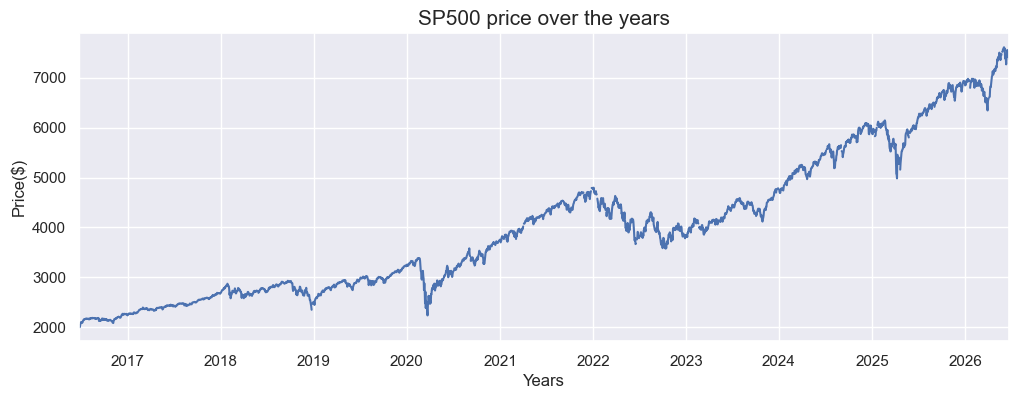

In [ ]:
# Pullin the raw data, We have the datetime as index and the price of the index as values
fred.get_series('SP500')

fred.get_series('SP500').plot(figsize=(12,4))
plt.xlabel('Years')
plt.ylabel('Price($)')
plt.title('SP500 price over the years', fontdict={'fontsize':'15'})
plt.show()

In [33]:
# We are going to search for unemplyment
unemp_restults = fred.search('unemployment')
unemp_restults.head() # We anow are going to select the first serie from the dataset. The one named 'UNRATE' in the series id

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
UNRATE,UNRATE,2026-07-09,2026-07-09,Unemployment Rate,1948-01-01,2026-06-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-07-02 08:31:40-05:00,96,The unemployment rate represents the number of...
UNRATENSA,UNRATENSA,2026-07-09,2026-07-09,Unemployment Rate,1948-01-01,2026-06-01,Monthly,M,Percent,%,Not Seasonally Adjusted,NSA,2026-07-02 08:31:40-05:00,55,The unemployment rate represents the number of...
UNEMPLOY,UNEMPLOY,2026-07-09,2026-07-09,Unemployment Level,1948-01-01,2026-06-01,Monthly,M,Thousands of Persons,Thous. of Persons,Seasonally Adjusted,SA,2026-07-02 08:31:34-05:00,69,The series comes from the 'Current Population ...
NROU,NROU,2026-07-09,2026-07-09,Noncyclical Rate of Unemployment,1949-01-01,2036-10-01,Quarterly,Q,Percent,%,Not Seasonally Adjusted,NSA,2026-02-27 15:05:27-06:00,65,"Starting with the July, 2021 report: An Update..."
U6RATE,U6RATE,2026-07-09,2026-07-09,"Total Unemployed, Plus All Persons Marginally ...",1994-01-01,2026-06-01,Monthly,M,Percent,%,Seasonally Adjusted,SA,2026-07-02 08:31:35-05:00,72,The series comes from the 'Current Population ...


In [34]:

unrate_search = fred.get_series('UNRATE')
unrate_search.head()
# We got as result a pandas series. as index we have the date and as values we have the percentage values for unemployment

1948-01-01    3.4
1948-02-01    3.8
1948-03-01    4.0
1948-04-01    3.9
1948-05-01    3.5
dtype: float64

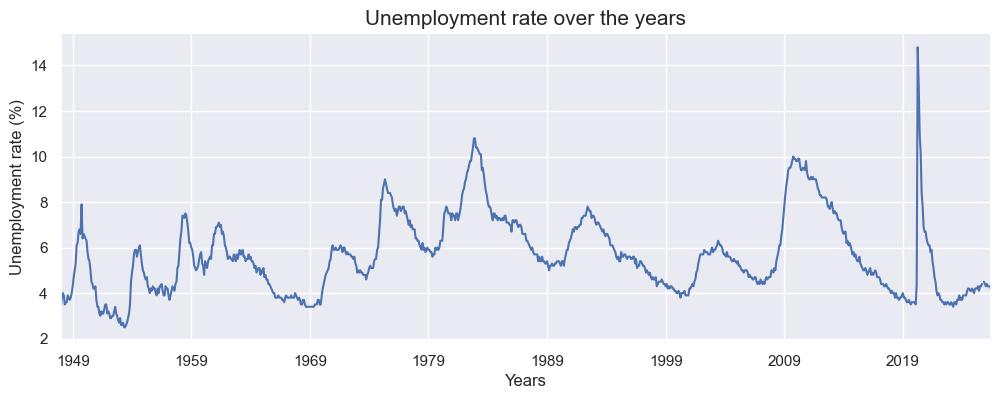

In [35]:

unrate_search.plot(figsize=(12,4))
plt.ylabel('Unemployment rate (%)')
plt.xlabel('Years')
plt.title('Unemployment rate over the years', fontdict={'fontsize':'15'})
plt.show()